## Data2Vec-Audio based phoneme recognition on TIMIT

This notebook mirrors the original Wav2Vec2-based phoneme recognition pipeline on the TIMIT dataset, but swaps the acoustic encoder for **Data2Vec-Audio** (default: `facebook/data2vec-audio-base-960h`). The dataset preparation, phoneme vocabulary, feature caching, CTC training loop, and layer/head benchmarking logic follow the same structure as in the original notebook.

To reduce compute, if the encoder exposes more than **15** layer positions (including the projection position at index 0), the notebook will automatically **subsample** layer indices for benchmarking and plotting.

In [ ]:
import kaggle

import os
import gc
import random
import json
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import IPython.display as ipd
import datasets

import torch
import torch.nn as nn
from transformers import AutoFeatureExtractor, AutoModelForCTC
from jiwer import wer

from torch.utils.data import DataLoader


from torch.utils.data import Dataset

from typing import List, Dict, Tuple
%matplotlib inline

SEED = 42

def set_seed(s: int = SEED) -> None:
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)

set_seed()

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print("Device:", DEVICE)

MODEL_NAME = "facebook/data2vec-audio-base-960h"
CACHE_DIR = "./cache/phoneme_features_data2vec"
RESULTS_DIR = "./results/data2vec"
CHECKPOINTS_DIR = "./weights/data2vec"
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)

Device: mps


In [2]:
timit = "./timit/"
timit_data = "./timit/data/"

df_train = pd.read_csv(os.path.join(timit, "train_data.csv"))
df_test = pd.read_csv(os.path.join(timit, "test_data.csv"))

df = pd.concat([df_train, df_test])
df = df[df["is_converted_audio"] == False]

df_train = df[df["test_or_train"] == "TRAIN"]
df_test = df[df["test_or_train"] == "TEST"]

print("Train rows:", len(df_train))
print("Test rows:", len(df_test))
print(df_train.head())
print(df_test.head())

Train rows: 18480
Test rows: 6720
   index test_or_train dialect_region speaker_id    filename  \
1    2.0         TRAIN            DR4      MMDM0  SI1311.PHN   
2    3.0         TRAIN            DR4      MMDM0  SI1311.WRD   
3    4.0         TRAIN            DR4      MMDM0   SX321.PHN   
4    5.0         TRAIN            DR4      MMDM0   SX321.WRD   
5    6.0         TRAIN            DR4      MMDM0   SI681.TXT   

           path_from_data_dir     path_from_data_dir_windows  \
1  TRAIN/DR4/MMDM0/SI1311.PHN  TRAIN\\DR4\\MMDM0\\SI1311.PHN   
2  TRAIN/DR4/MMDM0/SI1311.WRD  TRAIN\\DR4\\MMDM0\\SI1311.WRD   
3   TRAIN/DR4/MMDM0/SX321.PHN   TRAIN\\DR4\\MMDM0\\SX321.PHN   
4   TRAIN/DR4/MMDM0/SX321.WRD   TRAIN\\DR4\\MMDM0\\SX321.WRD   
5   TRAIN/DR4/MMDM0/SI681.TXT   TRAIN\\DR4\\MMDM0\\SI681.TXT   

  is_converted_audio is_audio is_word_file is_phonetic_file is_sentence_file  
1              False    False        False             True            False  
2              False    False         

In [3]:
PHONETIC = "phonetic"
AUDIO = "audio"
WORD = "word"

phon61_map39 = {
    "iy": "iy",  "ih": "ih",  "eh": "eh",  "ae": "ae",   "ix": "ih",  "ax": "ah",  "ah": "ah",   "uw": "uw",
    "ux": "uw",  "uh": "uh",  "ao": "aa",  "aa": "aa",   "ey": "ey",  "ay": "ay",  "oy": "oy",   "aw": "aw",
    "ow": "ow",  "l": "l",    "el": "l",   "r": "r",     "y": "y",    "w": "w",    "er": "er",   "axr": "er",
    "m": "m",    "em": "m",   "n": "n",    "nx": "n",    "en": "n",   "ng": "ng",  "eng": "ng",  "ch": "ch",
    "jh": "jh",  "dh": "dh",  "b": "b",    "d": "d",     "dx": "dx",  "g": "g",    "p": "p",     "t": "t",
    "k": "k",    "z": "z",    "zh": "sh",  "v": "v",     "f": "f",    "th": "th",  "s": "s",     "sh": "sh",
    "hh": "hh",  "hv": "hh",  "pcl": "h#", "tcl": "h#",  "kcl": "h#", "qcl": "h#", "bcl": "h#",  "dcl": "h#",
    "gcl": "h#", "h#": "h#",  "#h": "h#",  "pau": "h#",  "epi": "h#", "ax-h": "ah", "q": "h#"
}

def convert_phonetic_to_39(phonetic_map: Dict[str, str], sequence: str) -> str:
    return " ".join(phonetic_map.get(x, x) for x in sequence.split())


def read_text(text_file_path: str) -> str:
    with open(text_file_path, "r") as file:
        char = [line.split()[-1] for line in file]
        return " ".join(char)


def transform_dataset(df: pd.DataFrame) -> Dict[str, List[str]]:
    temp_data: Dict[str, Dict[str, str]] = {}
    keys_set = {AUDIO, WORD, PHONETIC}

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Processing items"):
        path = row["path_from_data_dir"]
        entry_id = "-".join(path.split(".")[0].split("/")[-2:])
        if entry_id not in temp_data:
            temp_data[entry_id] = {}

        full_path = os.path.join(timit_data, path)
        extension = os.path.splitext(path)[1].upper()

        if extension == ".WAV":
            temp_data[entry_id][AUDIO] = full_path
        elif extension == ".WRD":
            temp_data[entry_id][WORD] = read_text(full_path)
        elif extension == ".PHN":
            phoneme_sentence = read_text(full_path)
            temp_data[entry_id][PHONETIC] = convert_phonetic_to_39(phon61_map39, phoneme_sentence)

    results: Dict[str, List[str]] = {AUDIO: [], WORD: [], PHONETIC: []}

    for entry in temp_data.values():
        if set(entry.keys()) == keys_set:
            results[AUDIO].append(entry[AUDIO])
            results[WORD].append(entry[WORD])
            results[PHONETIC].append(entry[PHONETIC])

    return results

In [4]:
train_val = transform_dataset(df_train)
test = transform_dataset(df_test)

n = len(train_val[AUDIO])
train_n = int(n * 0.9)
val_n = n - train_n

val_ind = np.array(sorted(random.sample(range(n), val_n)))
train_ind = np.array(sorted(list(set(range(n)) - set(val_ind))))

train: Dict[str, List[str]] = {}
val: Dict[str, List[str]] = {}

for key in [AUDIO, WORD, PHONETIC]:
    train[key] = np.array(train_val[key])[train_ind].tolist()
    val[key] = np.array(train_val[key])[val_ind].tolist()

print("Train set length:", len(train[AUDIO]))
print("Validation set length:", len(val[AUDIO]))
print("Test set length:", len(test[AUDIO]))

Processing items: 100%|██████████| 6720/6720 [00:00<00:00, 13893.54it/s]

Train set length: 4158
Validation set length: 462
Test set length: 1680


In [5]:
splits = {
    "train": datasets.Dataset.from_dict(train),
    "val": datasets.Dataset.from_dict(val),
    "test": datasets.Dataset.from_dict(test),
}

for name in splits:
    splits[name] = splits[name].cast_column(
        AUDIO,
        datasets.Audio(sampling_rate=16_000),
    )

train_dataset = splits["train"]
val_dataset = splits["val"]
test_dataset = splits["test"]

ind = 10
sample = train_dataset[ind]

print(f"Text:           {sample[WORD]}")
print(f"Phonetics:      {sample[PHONETIC]}")
print(f"Array Shape:    {sample[AUDIO]['array'].shape}")
print(f"Sampling Rate:  {sample[AUDIO]['sampling_rate']}")

ipd.Audio(data=sample[AUDIO]["array"], autoplay=False, rate=16_000)

Text:           the coyote bobcat and hyena are wild animals
Phonetics:      h# dh ih h# k ay ow dx iy h# b aa h# b h# k ae h# n hh ay iy n ah h# aa r w aa l dx ae n ih m l z h#
Array Shape:    (58164,)
Sampling Rate:  16000


In [6]:
unique_phonemes = set([" "])

for dataset in [train_dataset, val_dataset, test_dataset]:
    for row in dataset:
        unique_phonemes.update(row[PHONETIC].split())

vocab_list = list(unique_phonemes)

vocab_dict: Dict[str, int] = {v: k for k, v in enumerate(sorted(vocab_list))}
print(vocab_dict)

vocab_dict["|"] = vocab_dict[" "]
del vocab_dict[" "]

vocab_dict["[UNK]"] = len(vocab_dict)
vocab_dict["[PAD]"] = len(vocab_dict)
print(len(vocab_dict))

with open("./vocab.json", "w") as vocab_file:
    json.dump(vocab_dict, vocab_file)

del df
del df_test
del df_train

{' ': 0, 'aa': 1, 'ae': 2, 'ah': 3, 'aw': 4, 'ay': 5, 'b': 6, 'ch': 7, 'd': 8, 'dh': 9, 'dx': 10, 'eh': 11, 'er': 12, 'ey': 13, 'f': 14, 'g': 15, 'h#': 16, 'hh': 17, 'ih': 18, 'iy': 19, 'jh': 20, 'k': 21, 'l': 22, 'm': 23, 'n': 24, 'ng': 25, 'ow': 26, 'oy': 27, 'p': 28, 'r': 29, 's': 30, 'sh': 31, 't': 32, 'th': 33, 'uh': 34, 'uw': 35, 'v': 36, 'w': 37, 'y': 38, 'z': 39}
42


## Data2Vec-Audio encoder and feature extraction

In [7]:
model = AutoModelForCTC.from_pretrained(MODEL_NAME, output_hidden_states=True).to(DEVICE)
feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_NAME)


def parameter_counter(input_model: nn.Module, model_name: str) -> None:
    counter = 0
    for param in input_model.parameters():
        counter += param.shape.numel()
    print(f"{model_name} Parameters Count: {counter/1_000_000:.1f}M")

parameter_counter(model, "Data2Vec")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/373M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

Data2Vec Parameters Count: 93.2M


In [8]:
ind = 0
audio_array = train_dataset[ind][AUDIO]["array"]
sampling_rate = train_dataset[ind][AUDIO]["sampling_rate"]

inputs = feature_extractor(
    audio_array,
    sampling_rate=sampling_rate,
    return_tensors="pt",
    padding=True,
).to(DEVICE)

model.eval()
with torch.no_grad():
    outputs = model(**inputs)

hidden_states = outputs.hidden_states

for i, hs in enumerate(hidden_states):
    print(f"Layer {i}: {hs.shape}")

Layer 0: torch.Size([1, 270, 768])
Layer 1: torch.Size([1, 270, 768])
Layer 2: torch.Size([1, 270, 768])
Layer 3: torch.Size([1, 270, 768])
Layer 4: torch.Size([1, 270, 768])
Layer 5: torch.Size([1, 270, 768])
Layer 6: torch.Size([1, 270, 768])
Layer 7: torch.Size([1, 270, 768])
Layer 8: torch.Size([1, 270, 768])
Layer 9: torch.Size([1, 270, 768])
Layer 10: torch.Size([1, 270, 768])
Layer 11: torch.Size([1, 270, 768])
Layer 12: torch.Size([1, 270, 768])


In [ ]:
class PhonemeDataset(Dataset):
    def __init__(self, data, layer_index: int, split_name: str, cache_dir: str = CACHE_DIR):
        self.items = []
        self.extra = []
        self.layer_index = layer_index
        self.split_name = split_name

        os.makedirs(cache_dir, exist_ok=True)
        cache_path = os.path.join(cache_dir, f"{split_name}_layer_{layer_index}.pt")

        if os.path.exists(cache_path):
            payload = torch.load(cache_path, map_location="cpu", weights_only=False)
            self.items = payload["items"]
            self.extra = payload["extra"]
            print(f"Loaded cached Data2Vec features for {split_name}, layer {layer_index}")
            return

        print(f"Extracting Data2Vec features for {split_name}, layer {layer_index}...")

        for row in tqdm(data, desc=f"Processing {split_name} rows"):
            inputs = feature_extractor(
                row[AUDIO]["array"],
                sampling_rate=row[AUDIO]["sampling_rate"],
                return_tensors="pt",
                padding=True,
            ).input_values.to(DEVICE)

            with torch.no_grad():
                hidden_states = model(input_values=inputs, output_hidden_states=True).hidden_states
                features = hidden_states[layer_index].squeeze(0).cpu()

            phoneme_ids = [vocab_dict.get(token, vocab_dict["[UNK]"]) for token in row[PHONETIC].split()]
            labels = torch.tensor(phoneme_ids, dtype=torch.long)

            self.items.append({"features": features, "labels": labels})
            self.extra.append({
                AUDIO: row[AUDIO],
                WORD: row[WORD],
                PHONETIC: row[PHONETIC],
            })

        torch.save({"items": self.items, "extra": self.extra}, cache_path)
        print(f"Saved cached Data2Vec features to {cache_path}")

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, idx: int) -> dict:
        return self.items[idx]

    def get_extra_data(self, idx: int) -> dict:
        return self.extra[idx]

In [10]:
def layer_position_to_name(layer_index: int) -> str:
    return "feature_projection" if layer_index == 0 else f"encoder_{layer_index}"


def build_layer_datasets(layer_index: int):
    train_ds = PhonemeDataset(train_dataset, layer_index=layer_index, split_name="train")
    val_ds = PhonemeDataset(val_dataset, layer_index=layer_index, split_name="val")
    test_ds = PhonemeDataset(test_dataset, layer_index=layer_index, split_name="test")
    return train_ds, val_ds, test_ds


available_layer_indices = list(range(model.config.num_hidden_layers + 1))
default_layer_index = available_layer_indices[-1]

MAX_LAYER_POSITIONS = 15
if len(available_layer_indices) <= MAX_LAYER_POSITIONS:
    selected_layer_indices = available_layer_indices
else:
    selected_layer_indices = sorted(set(int(round(x)) for x in np.linspace(0, available_layer_indices[-1], MAX_LAYER_POSITIONS)))
    if 0 not in selected_layer_indices:
        selected_layer_indices = [0] + selected_layer_indices
    selected_layer_indices = sorted(set(selected_layer_indices))

print("Available layer indices:", available_layer_indices)
print(f"Selected layer indices (cap={MAX_LAYER_POSITIONS}):", selected_layer_indices)

train_dataset_torch, val_dataset_torch, test_dataset_torch = build_layer_datasets(default_layer_index)
print(f"Prepared default Data2Vec datasets for {layer_position_to_name(default_layer_index)}")

Available layer indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Selected layer indices (cap=15): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Extracting Data2Vec features for train, layer 12...


Processing train rows:   0%|          | 2/4158 [00:00<06:37, 10.44it/s]

model.safetensors:   0%|          | 0.00/373M [00:00<?, ?B/s]

Processing train rows: 100%|██████████| 4158/4158 [02:34<00:00, 26.85it/s]


Saved cached Data2Vec features to ./cache/phoneme_features_data2vec/train_layer_12.pt
Extracting Data2Vec features for val, layer 12...


Processing val rows: 100%|██████████| 462/462 [00:22<00:00, 20.69it/s]


Saved cached Data2Vec features to ./cache/phoneme_features_data2vec/val_layer_12.pt
Extracting Data2Vec features for test, layer 12...


Processing test rows: 100%|██████████| 1680/1680 [01:01<00:00, 27.45it/s]


Saved cached Data2Vec features to ./cache/phoneme_features_data2vec/test_layer_12.pt
Prepared default Data2Vec datasets for encoder_12


In [ ]:
class LinearHead(nn.Module):
    def __init__(self, input_dim: int, output_dim: int):
        super().__init__()
        self.fc = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.fc(x)


class MLPHead(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.net(x)


class RecurrentHead(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, num_layers: int = 1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out)


class Conv1DHead(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, kernel_size: int = 5):
        super().__init__()
        padding = kernel_size // 2

        self.conv = nn.Conv1d(
            in_channels=input_dim,
            out_channels=hidden_dim,
            kernel_size=kernel_size,
            padding=padding,
        )
        self.activation = nn.ReLU()
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv(x)
        x = self.activation(x)
        x = x.transpose(1, 2)
        return self.fc(x)


class LiteConformerHead(nn.Module):
    def __init__(self, input_dim: int, output_dim: int, num_heads: int = 4, kernel_size: int = 5):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim=input_dim, num_heads=num_heads, batch_first=True)

        padding = kernel_size // 2
        self.conv = nn.Conv1d(
            in_channels=input_dim,
            out_channels=input_dim,
            kernel_size=kernel_size,
            padding=padding,
            groups=input_dim,
        )

        self.fc = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        attn_out, _ = self.attention(x, x, x)
        x = x + attn_out
        x_conv = x.transpose(1, 2)
        x_conv = self.conv(x_conv)
        x = x + x_conv.transpose(1, 2)
        return self.fc(x)

In [12]:
def custom_collate_fn(batch_items: list):
    seqs = [item["features"] for item in batch_items]
    targets = [item["labels"] for item in batch_items]

    input_lengths = torch.tensor([seq.shape[0] for seq in seqs], dtype=torch.long)
    x_padded = torch.nn.utils.rnn.pad_sequence(seqs, batch_first=True)

    y_flat = torch.cat(targets).long()
    target_lengths = torch.tensor([len(y) for y in targets], dtype=torch.long)

    return x_padded, input_lengths, y_flat, target_lengths


def decode_ctc_predictions(model_head: nn.Module, x_features: torch.Tensor, id2char: dict, blank_id: int) -> str:
    model_head.eval()
    with torch.no_grad():
        logits = model_head(x_features.to(DEVICE)).cpu()

    predicted_ids = logits.argmax(dim=-1).squeeze(0).tolist()
    collapsed_phonemes = []
    previous_id = None
    ignored_tokens = {"|", "[PAD]", "[UNK]"}

    for current_id in predicted_ids:
        if current_id != previous_id and current_id != blank_id:
            token = id2char.get(current_id, "")
            if token and token not in ignored_tokens:
                collapsed_phonemes.append(token)
        previous_id = current_id

    return " ".join(collapsed_phonemes).strip()


def evaluate_and_display_sample(model_head: nn.Module, dataset, index: int, id2char: dict, blank_id: int):
    metadata = dataset.get_extra_data(index)
    actual_text = metadata[WORD]
    actual_phonemes = metadata[PHONETIC]
    raw_audio = metadata[AUDIO]["array"]
    sample_features = dataset[index]["features"].unsqueeze(0)
    hypothesis = decode_ctc_predictions(model_head, sample_features, id2char, blank_id)

    print(f"Original Text: {actual_text}")
    print(f"Phone Error Rate (PER): {wer(reference=actual_phonemes, hypothesis=hypothesis):.3f}")
    print(f"Ground Truth: {actual_phonemes}")
    print(f"Model Output: {hypothesis}")

    return raw_audio

In [ ]:
def decode_batch_predictions(logits: torch.Tensor, input_lengths: torch.Tensor, id2char: Dict[int, str], blank_idx: int) -> list[str]:
    predicted_ids = logits.argmax(dim=-1)
    ignored_tokens = {"|", "[PAD]", "[UNK]"}
    decoded_sequences: list[str] = []

    for batch_idx, seq_len in enumerate(input_lengths.tolist()):
        pred_tokens = []
        previous_token = None
        for current_token in predicted_ids[batch_idx, :seq_len].tolist():
            if current_token != previous_token and current_token != blank_idx:
                token = id2char.get(current_token, "")
                if token and token not in ignored_tokens:
                    pred_tokens.append(token)
            previous_token = current_token
        decoded_sequences.append(" ".join(pred_tokens))

    return decoded_sequences


def run_train_step(network: nn.Module, dataloader: DataLoader, loss_fn: nn.Module, optim: torch.optim.Optimizer, hide_progress: bool = False) -> float:
    network.train()
    cumulative_loss = 0.0
    valid_steps = 0

    for x_batch, x_lengths, y_flat, y_lengths in tqdm(dataloader, disable=hide_progress, desc="Training"):
        x_batch = x_batch.to(DEVICE)
        x_lengths = x_lengths.to(DEVICE)
        y_flat = y_flat.to(DEVICE)
        y_lengths = y_lengths.to(DEVICE)

        optim.zero_grad()
        predictions = network(x_batch)
        log_probs = predictions.log_softmax(dim=-1).transpose(0, 1)

        if DEVICE.type == "mps":
            cost = loss_fn(log_probs.cpu(), y_flat.cpu(), x_lengths.cpu(), y_lengths.cpu())
        else:
            cost = loss_fn(log_probs, y_flat, x_lengths, y_lengths)

        if not torch.isfinite(cost):
            continue

        cost.backward()
        optim.step()

        cumulative_loss += cost.item()
        valid_steps += 1

    return cumulative_loss / max(valid_steps, 1)


def compute_validation_metric(network: nn.Module, dataloader: DataLoader, id2char: Dict[int, str], blank_idx: int, hide_progress: bool = False) -> float:
    network.eval()
    total_error_rate = 0.0
    sample_count = 0
    ignored_tokens = {"|", "[PAD]", "[UNK]"}

    with torch.no_grad():
        for x_batch, x_lengths, y_flat, y_lengths in tqdm(dataloader, disable=hide_progress, desc="Evaluating"):
            logits = network(x_batch.to(DEVICE)).cpu()
            decoded_predictions = decode_batch_predictions(logits, x_lengths, id2char, blank_idx)

            offset = 0
            for sample_idx, target_len in enumerate(y_lengths.tolist()):
                target_ids = y_flat[offset:offset + target_len].tolist()
                truth_tokens = [id2char[val] for val in target_ids if val in id2char and id2char[val] not in ignored_tokens]
                truth_string = " ".join(truth_tokens)
                pred_string = decoded_predictions[sample_idx]

                total_error_rate += wer(reference=truth_string, hypothesis=pred_string)
                sample_count += 1
                offset += target_len

    return total_error_rate / max(sample_count, 1)


def execute_training_loop(
    network: nn.Module,
    train_dl: DataLoader,
    val_dl: DataLoader,
    loss_fn: nn.Module,
    optim: torch.optim.Optimizer,
    id2char: Dict[int, str],
    blank_idx: int,
    save_path: str,
    test_dl: DataLoader | None = None,
    max_epochs: int = 100,
    top_per: float = float("inf"),
    hide_progress: bool = False,
) -> Tuple[list[dict], float, float, float, int]:
    history: list[dict] = []
    best_test_per = float("nan")
    best_epoch = -1
    avg_loss = float("nan")
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    for epoch in range(max_epochs):
        avg_loss = run_train_step(network, train_dl, loss_fn, optim, hide_progress)
        current_per = compute_validation_metric(network, val_dl, id2char, blank_idx, hide_progress)
        current_test_per = None
        if test_dl is not None:
            current_test_per = compute_validation_metric(network, test_dl, id2char, blank_idx, hide_progress)

        history.append(
            {
                "epoch": epoch + 1,
                "train_loss": avg_loss,
                "val_per": current_per,
                "test_per": current_test_per,
            }
        )

        if current_per < top_per:
            torch.save(network.state_dict(), save_path)
            top_per = current_per
            best_test_per = current_test_per if current_test_per is not None else float("nan")
            best_epoch = epoch + 1

        if not hide_progress:
            test_msg = f" | Test PER: {current_test_per:.4f}" if current_test_per is not None else ""
            print(
                f"Epoch [{epoch + 1:03d}/{max_epochs:03d}] | "
                f"Loss: {avg_loss:.4f} | "
                f"Val PER: {current_per:.4f}{test_msg} | "
                f"Best Val PER: {top_per:.4f}"
            )

    return history, avg_loss, top_per, best_test_per, best_epoch

In [14]:
id_to_token = {val: key for key, val in vocab_dict.items()}

audio_feature_dim = model.config.hidden_size
train_batch_size = 16
blank_token_id = len(vocab_dict)
num_classes = blank_token_id + 1
learning_rate = 1e-4
total_epochs = 10


def release_memory() -> None:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if hasattr(torch, "mps") and torch.backends.mps.is_available():
        torch.mps.empty_cache()


def build_model_zoo(input_dim: int, output_dim: int) -> dict:
    return {
        "Linear": LinearHead(input_dim=input_dim, output_dim=output_dim),
        "MLP": MLPHead(input_dim=input_dim, hidden_dim=512, output_dim=output_dim, dropout=0.5),
        "BiLSTM": RecurrentHead(input_dim=input_dim, hidden_dim=256, output_dim=output_dim, num_layers=1),
        "Conv1D": Conv1DHead(input_dim=input_dim, hidden_dim=512, output_dim=output_dim, kernel_size=5),
        "LiteConformer": LiteConformerHead(input_dim=input_dim, output_dim=output_dim, num_heads=4, kernel_size=5),
    }


def persist_benchmark_outputs(summary_rows: list[dict], history_rows: list[dict]) -> None:
    summary_df = pd.DataFrame(summary_rows)
    if not summary_df.empty:
        summary_df = summary_df.sort_values(["best_val_per", "final_test_per"], ascending=[True, True])
        summary_df.to_csv(os.path.join(RESULTS_DIR, "benchmark_data2vec_summary.csv"), index=False)
        summary_df.to_json(os.path.join(RESULTS_DIR, "benchmark_summary.json"), orient="records", indent=2)

    history_df = pd.DataFrame(history_rows)
    history_df.to_csv(os.path.join(RESULTS_DIR, "benchmark_data2vec_history.csv"), index=False)
    history_df.to_json(os.path.join(RESULTS_DIR, "benchmark_data2vec_history.json"), orient="records", indent=2)


benchmark_summary: list[dict] = []
benchmark_history: list[dict] = []

print("Starting Data2Vec Layer-by-Layer Architecture Benchmarking...")

for layer_index in selected_layer_indices:
    layer_name = layer_position_to_name(layer_index)
    print("\n" + "#" * 60)
    print(f"LAYER POSITION: {layer_name} (index={layer_index})")
    print("#" * 60)

    train_dataset_torch, val_dataset_torch, test_dataset_torch = build_layer_datasets(layer_index)

    train_dl = DataLoader(train_dataset_torch, batch_size=train_batch_size, shuffle=True, collate_fn=custom_collate_fn)
    val_dl = DataLoader(val_dataset_torch, batch_size=1, shuffle=False, collate_fn=custom_collate_fn)
    test_dl = DataLoader(test_dataset_torch, batch_size=1, shuffle=False, collate_fn=custom_collate_fn)
    ctc_criterion = nn.CTCLoss(blank=blank_token_id, zero_infinity=True)

    for model_name, current_network in build_model_zoo(audio_feature_dim, num_classes).items():
        print("\n" + "=" * 50)
        print(f" TRAINING HEAD: {model_name} | LAYER: {layer_name}")
        print("=" * 50)

        current_network = current_network.to(DEVICE)
        adam_optimizer = torch.optim.Adam(current_network.parameters(), lr=learning_rate)
        save_file = os.path.join(CHECKPOINTS_DIR, f"{layer_name}_{model_name.lower()}_head.pt")

        history, final_train_loss, best_val_per, best_test_per, best_epoch = execute_training_loop(
            network=current_network,
            train_dl=train_dl,
            val_dl=val_dl,
            test_dl=test_dl,
            loss_fn=ctc_criterion,
            optim=adam_optimizer,
            id2char=id_to_token,
            blank_idx=blank_token_id,
            save_path=save_file,
            max_epochs=total_epochs,
        )

        if os.path.exists(save_file):
            current_network.load_state_dict(torch.load(save_file, map_location="cpu"))
            current_network = current_network.to(DEVICE)

        final_test_per = compute_validation_metric(
            network=current_network,
            dataloader=test_dl,
            id2char=id_to_token,
            blank_idx=blank_token_id,
        )

        summary_row = {
            "layer_index": layer_index,
            "layer_name": layer_name,
            "head": model_name,
            "final_train_loss": final_train_loss,
            "best_val_per": best_val_per,
            "test_per_at_best_val": best_test_per,
            "final_test_per": final_test_per,
            "best_epoch": best_epoch,
            "checkpoint_path": save_file,
        }
        benchmark_summary.append(summary_row)

        for epoch_row in history:
            benchmark_history.append(
                {
                    "layer_index": layer_index,
                    "layer_name": layer_name,
                    "head": model_name,
                    **epoch_row,
                }
            )

        persist_benchmark_outputs(benchmark_summary, benchmark_history)

        del current_network
        del adam_optimizer
        del history
        release_memory()

    del train_dl
    del val_dl
    del test_dl
    del train_dataset_torch
    del val_dataset_torch
    del test_dataset_torch
    del ctc_criterion
    release_memory()

leaderboard = pd.DataFrame(benchmark_summary).sort_values(["best_val_per", "final_test_per"], ascending=[True, True])
print("\n" + "DATA2VEC BENCHMARKING COMPLETE".center(70))
print("=" * 70)
print(leaderboard[["layer_name", "head", "best_val_per", "test_per_at_best_val", "final_test_per", "best_epoch"]].to_string(index=False))
print("=" * 70)
print(f"Saved summary to {os.path.join(RESULTS_DIR, 'benchmark_data2vec_summary.csv')}")
print(f"Saved history to {os.path.join(RESULTS_DIR, 'benchmark_data2vec_history.csv')}")
release_memory()

Starting Data2Vec Layer-by-Layer Architecture Benchmarking...

############################################################
LAYER POSITION: feature_projection (index=0)
############################################################
Extracting Data2Vec features for train, layer 0...


Processing train rows: 100%|██████████| 4158/4158 [02:40<00:00, 25.90it/s]


Saved cached Data2Vec features to ./cache/phoneme_features_data2vec/train_layer_0.pt
Extracting Data2Vec features for val, layer 0...


Processing val rows: 100%|██████████| 462/462 [00:18<00:00, 25.25it/s]


Saved cached Data2Vec features to ./cache/phoneme_features_data2vec/val_layer_0.pt
Extracting Data2Vec features for test, layer 0...


...

Epoch [009/010] | Loss: 0.8804 | Val PER: 0.2608 | Test PER: 0.2563 | Best Val PER: 0.2608


Evaluating: 100%|██████████| 1680/1680 [00:12<00:00, 129.58it/s]


Epoch [010/010] | Loss: 0.8079 | Val PER: 0.2470 | Test PER: 0.2434 | Best Val PER: 0.2470


Evaluating: 100%|██████████| 1680/1680 [00:12<00:00, 132.05it/s]



                    DATA2VEC BENCHMARKING COMPLETE                    
        layer_name          head  best_val_per  test_per_at_best_val  final_test_per  best_epoch
         encoder_9        Conv1D      0.102304              0.101105        0.101105           9
         encoder_7        Conv1D      0.103827              0.105332        0.105332          10
         encoder_9        BiLSTM      0.104021              0.103151        0.103151          10
         encoder_8        BiLSTM      0.107520              0.106473        0.106473           9
        encoder_10        Conv1D      0.109301              0.106169        0.106169          10
         encoder_7        BiLSTM      0.110246              0.110223        0.110223          10
        encoder_10        BiLSTM      0.113746              0.109606        0.109606          10
         encoder_5        Conv1D      0.114089              0.113807        0.113807          10
         encoder_4        Conv1D      0.115476         

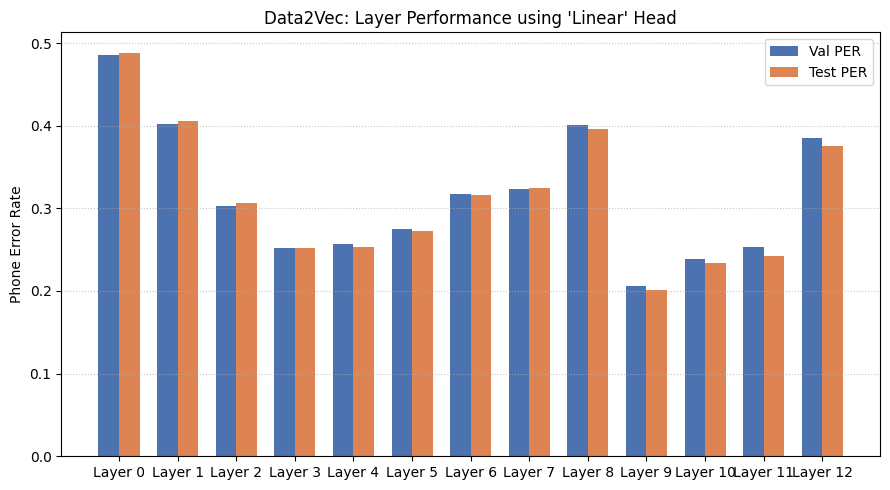

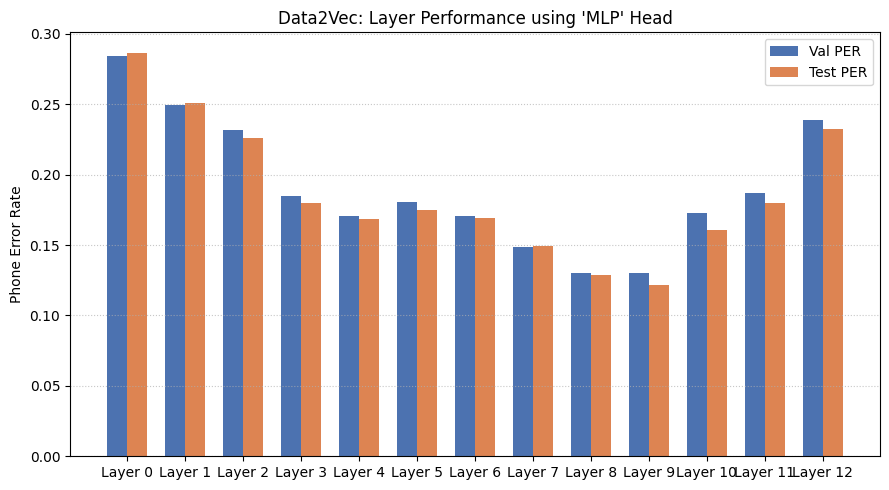

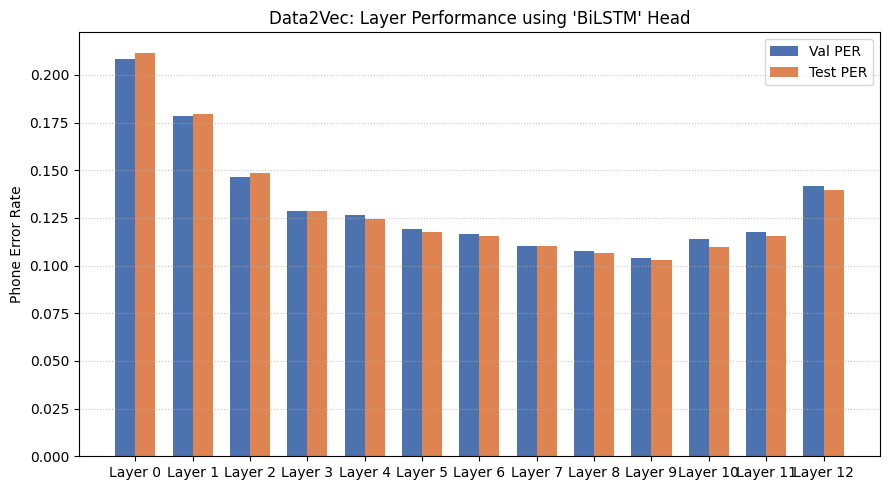

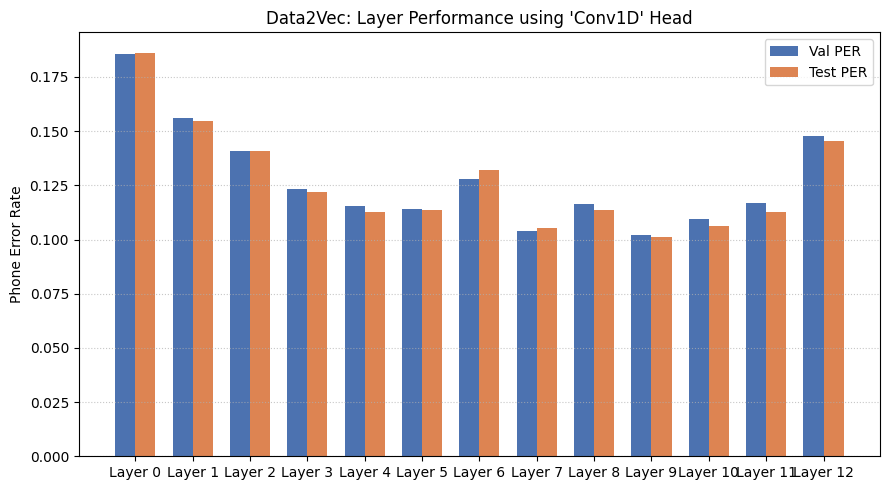

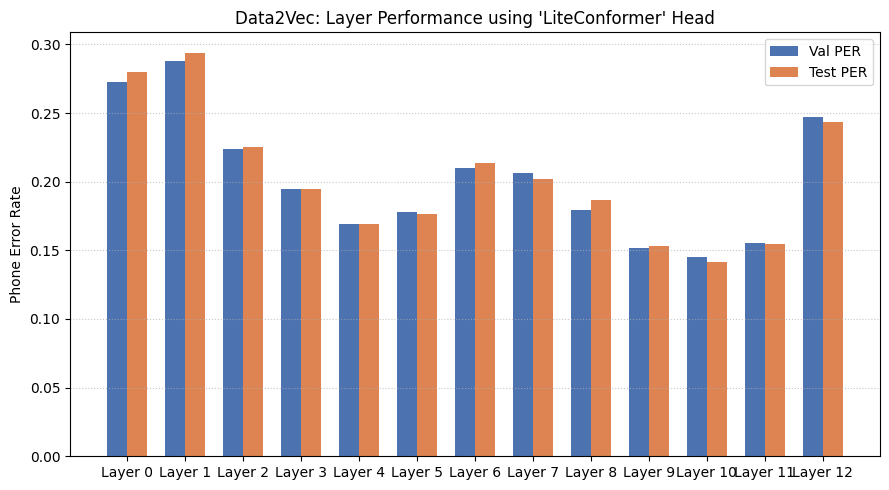

Plotting head-comparison charts for layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


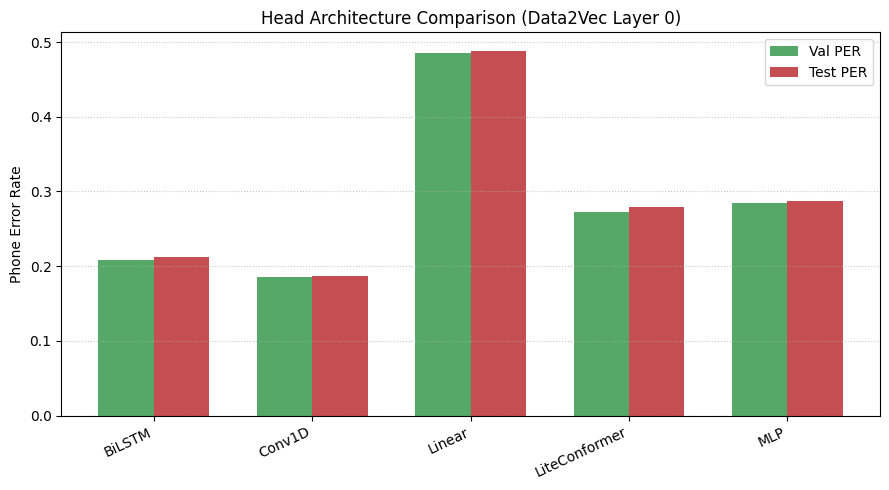

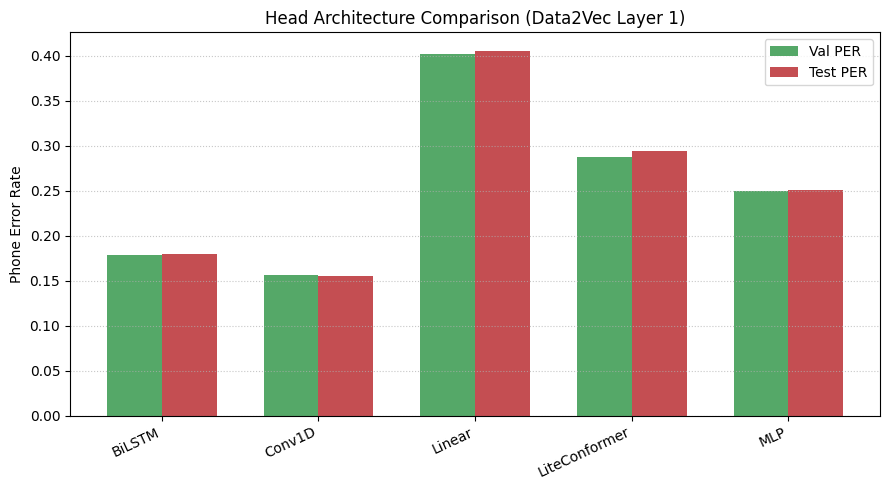

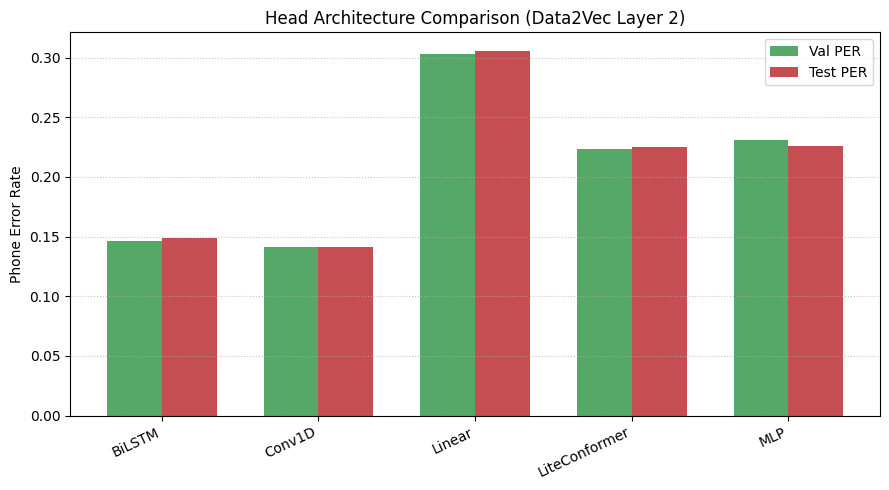

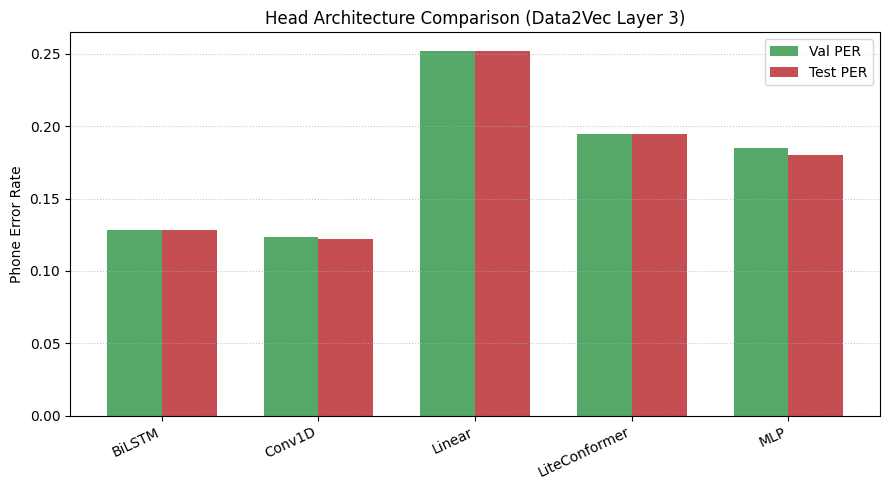

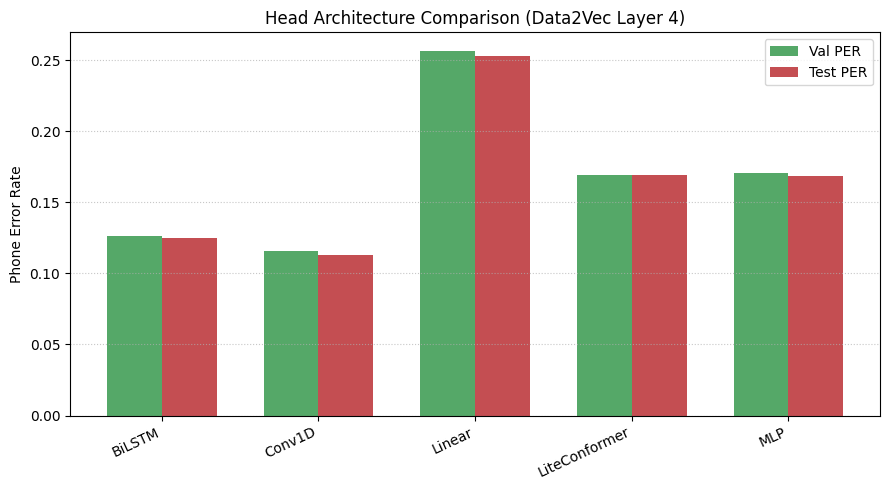

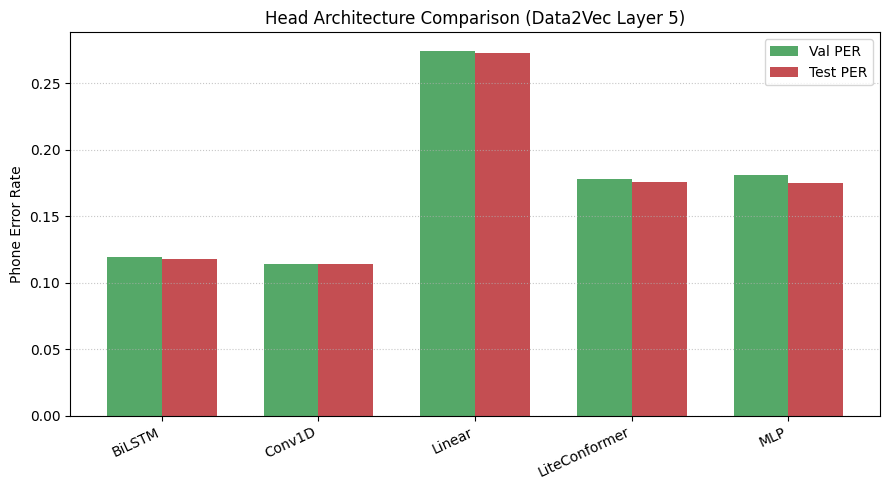

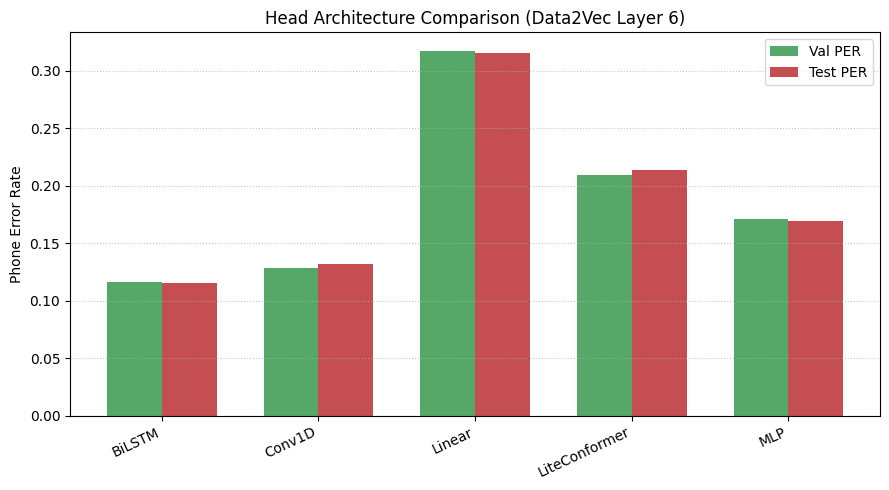

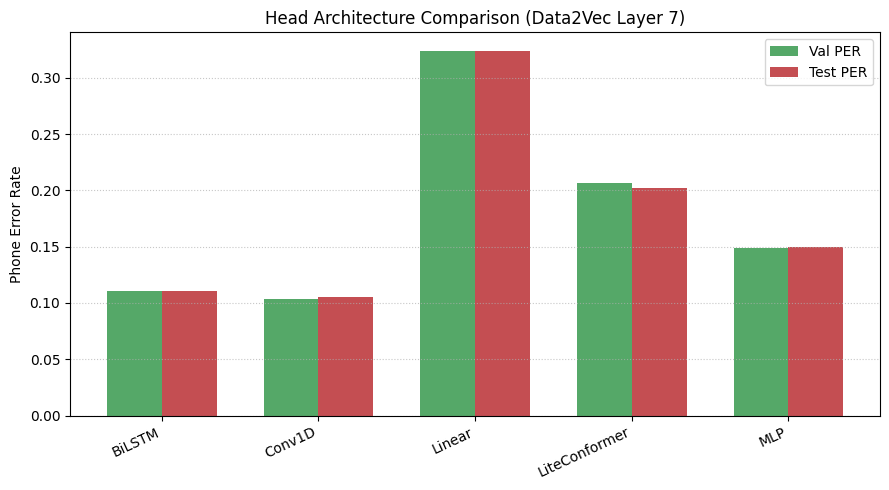

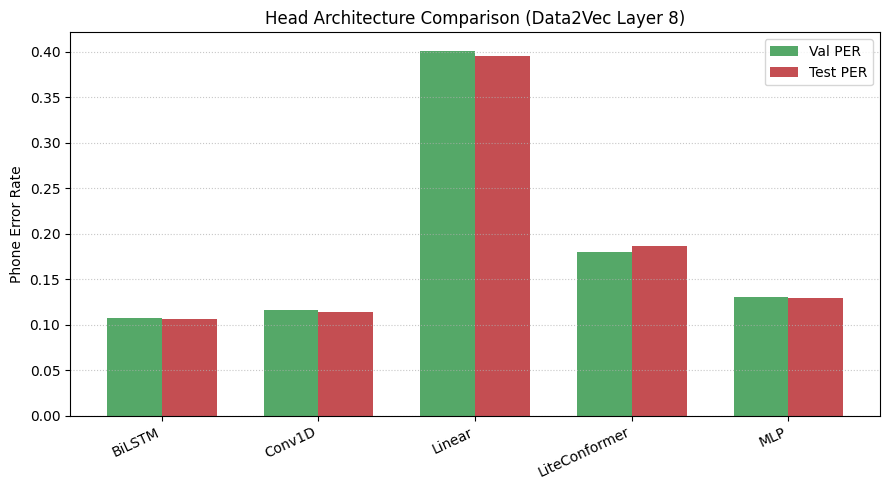

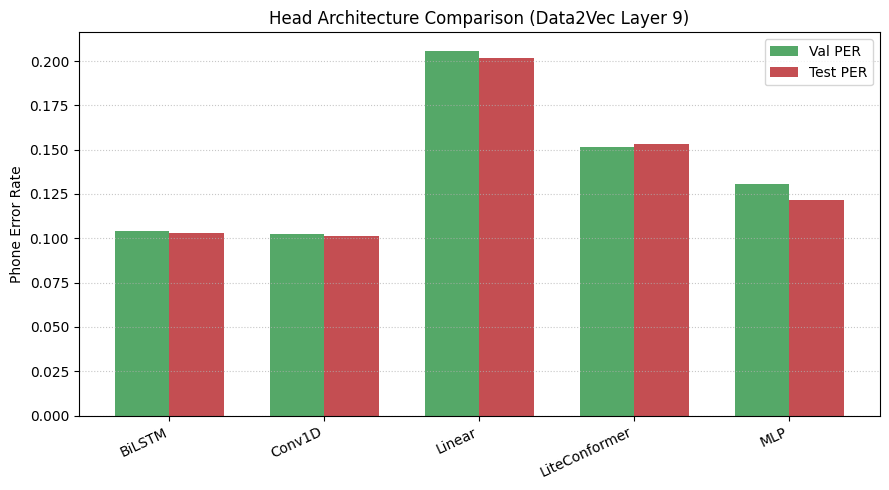

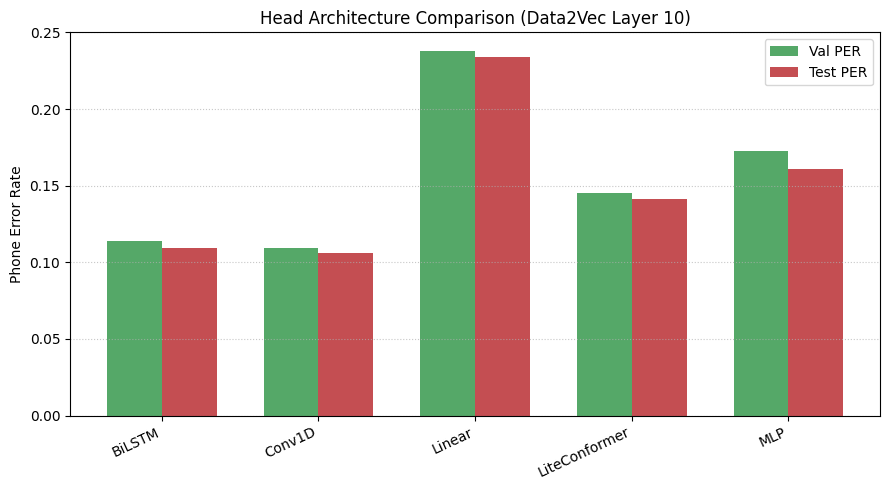

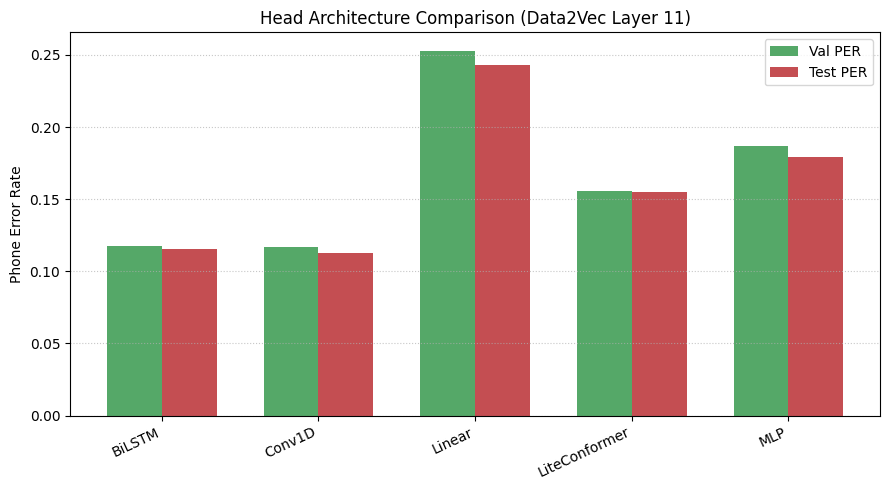

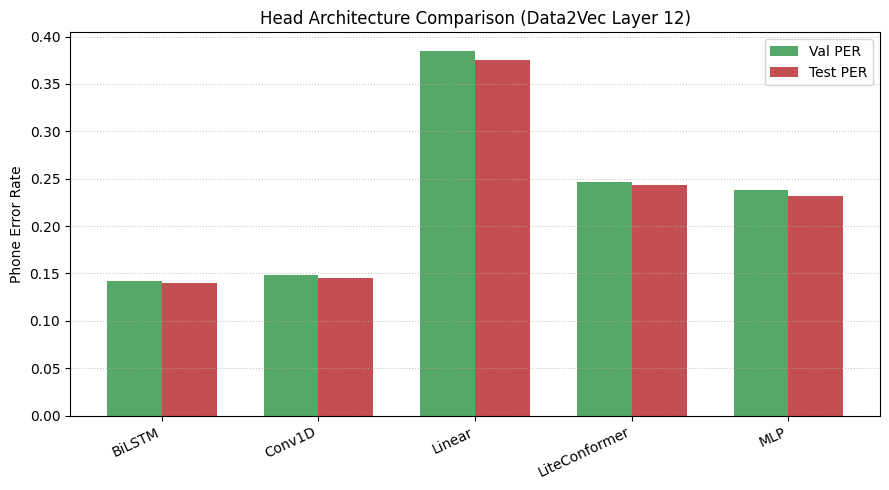

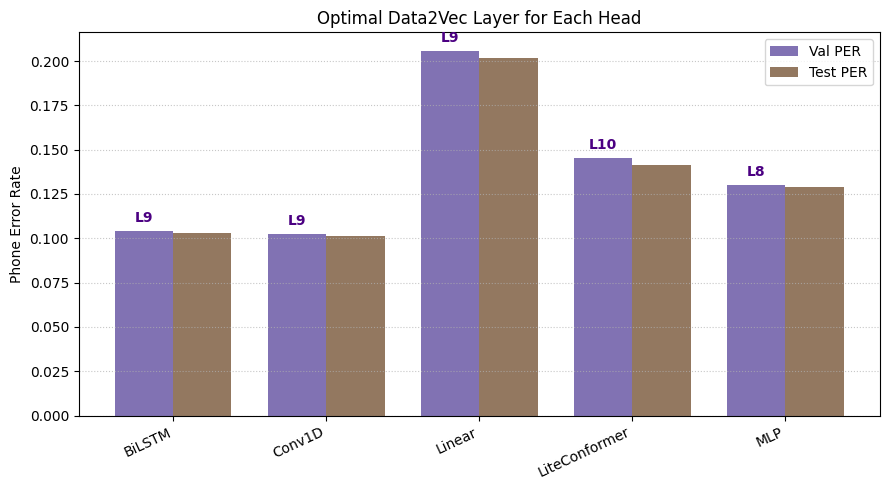

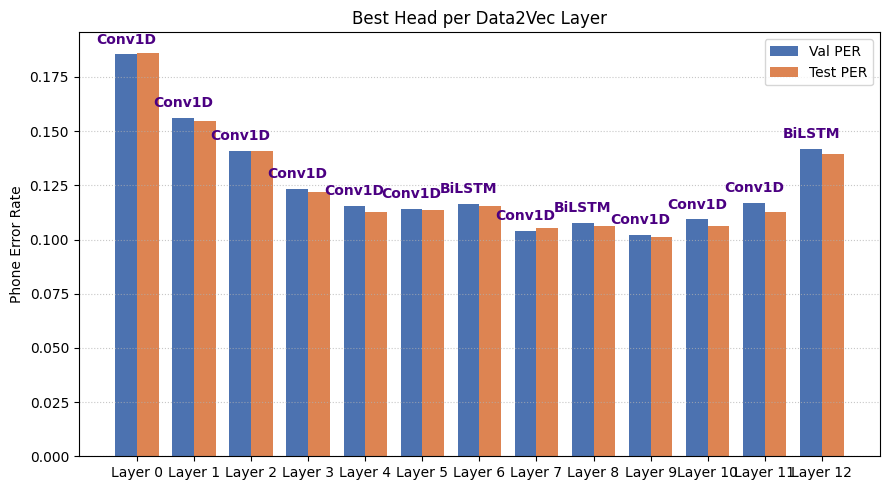

In [ ]:
def load_and_process_logs(json_file_path: str) -> pd.DataFrame:
    df_logs = pd.read_json(json_file_path)
    best_indices = df_logs.groupby(["layer_index", "head"])["val_per"].idxmin()
    return df_logs.loc[best_indices].reset_index(drop=True)


def chart_layer_metrics(df_best: pd.DataFrame, base_model_name: str, target_head: str | None = None):
    fig, ax = plt.subplots(figsize=(9, 5))
    bar_width = 0.35

    if target_head:
        plot_data = df_best[df_best["head"] == target_head].sort_values("layer_index")
        chart_title = f"{base_model_name}: Layer Performance using '{target_head}' Head"
    else:
        plot_data = df_best.groupby("layer_index")[['val_per', 'test_per']].mean().reset_index()
        chart_title = f"{base_model_name}: Average Layer Performance (All Heads)"

    x_positions = np.arange(len(plot_data))

    ax.bar(x_positions - bar_width / 2, plot_data["val_per"], width=bar_width, label="Val PER", color="#4C72B0")
    ax.bar(x_positions + bar_width / 2, plot_data["test_per"], width=bar_width, label="Test PER", color="#DD8452")

    ax.set_xticks(x_positions)
    ax.set_xticklabels([f"Layer {int(idx)}" for idx in plot_data["layer_index"]])
    ax.set_ylabel("Phone Error Rate")
    ax.set_title(chart_title)
    ax.grid(axis="y", linestyle=":", alpha=0.7)
    ax.legend()

    plt.tight_layout()
    plt.show()


def chart_head_metrics(df_best: pd.DataFrame, base_model_name: str, target_layer: int | None = None):
    fig, ax = plt.subplots(figsize=(9, 5))
    bar_w = 0.35

    if target_layer is not None:
        plot_data = df_best[df_best["layer_index"] == target_layer].sort_values("head")
        chart_title = f"Head Architecture Comparison ({base_model_name} Layer {target_layer})"
    else:
        plot_data = df_best.groupby("head")[['val_per', 'test_per']].mean().reset_index()
        chart_title = "Average Head Architecture Comparison"

    x_positions = np.arange(len(plot_data))

    ax.bar(x_positions - bar_w / 2, plot_data["val_per"], width=bar_w, label="Val PER", color="#55A868")
    ax.bar(x_positions + bar_w / 2, plot_data["test_per"], width=bar_w, label="Test PER", color="#C44E52")

    ax.set_xticks(x_positions)
    ax.set_xticklabels(plot_data["head"], rotation=25, ha="right")
    ax.set_ylabel("Phone Error Rate")
    ax.set_title(chart_title)
    ax.grid(axis="y", linestyle=":", alpha=0.7)
    ax.legend()

    plt.tight_layout()
    plt.show()


def highlight_top_layer_per_head(df_best: pd.DataFrame, base_model_name: str):
    top_indices = df_best.groupby("head")["val_per"].idxmin()
    top_data = df_best.loc[top_indices].reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(9, 5))
    x_pos = np.arange(len(top_data))
    bw = 0.38

    ax.bar(x_pos - bw / 2, top_data["val_per"], width=bw, label="Val PER", color="#8172B3")
    ax.bar(x_pos + bw / 2, top_data["test_per"], width=bw, label="Test PER", color="#937860")

    for index, row in top_data.iterrows():
        label_text = f"L{int(row['layer_index'])}"
        ax.text(index - bw / 2, row["val_per"] + 0.005, label_text, ha="center", fontweight="bold", color="indigo")

    ax.set_xticks(x_pos)
    ax.set_xticklabels(top_data["head"], rotation=25, ha="right")
    ax.set_ylabel("Phone Error Rate")
    ax.set_title(f"Optimal {base_model_name} Layer for Each Head")
    ax.grid(axis="y", linestyle=":", alpha=0.7)
    ax.legend()

    plt.tight_layout()
    plt.show()


def highlight_top_head_per_layer(df_best: pd.DataFrame, base_model_name: str):
    top_indices = df_best.groupby("layer_index")["val_per"].idxmin()
    top_data = df_best.loc[top_indices].reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(9, 5))
    x_pos = np.arange(len(top_data))
    bw = 0.38

    ax.bar(x_pos - bw / 2, top_data["val_per"], width=bw, label="Val PER", color="#4C72B0")
    ax.bar(x_pos + bw / 2, top_data["test_per"], width=bw, label="Test PER", color="#DD8452")

    for index, row in top_data.iterrows():
        label_text = row["head"]
        ax.text(index - bw / 2, row["val_per"] + 0.005, label_text, ha="center", fontweight="bold", color="indigo")

    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"Layer {int(idx)}" for idx in top_data["layer_index"]])
    ax.set_ylabel("Phone Error Rate")
    ax.set_title(f"Best Head per {base_model_name} Layer")
    ax.grid(axis="y", linestyle=":", alpha=0.7)
    ax.legend()

    plt.tight_layout()
    plt.show()


my_data_file = os.path.join(RESULTS_DIR, "benchmark_data2vec_shistory.json")

if os.path.exists(my_data_file):
    processed_df = load_and_process_logs(my_data_file)

    chart_layer_metrics(processed_df, base_model_name="Data2Vec", target_head="Linear")
    chart_layer_metrics(processed_df, base_model_name="Data2Vec", target_head="MLP")
    chart_layer_metrics(processed_df, base_model_name="Data2Vec", target_head="BiLSTM")
    chart_layer_metrics(processed_df, base_model_name="Data2Vec", target_head="Conv1D")
    chart_layer_metrics(processed_df, base_model_name="Data2Vec", target_head="LiteConformer")

    print("Plotting head-comparison charts for layers:", selected_layer_indices)
    for layer_idx in selected_layer_indices:
        chart_head_metrics(processed_df, base_model_name="Data2Vec", target_layer=layer_idx)

    highlight_top_layer_per_head(processed_df, base_model_name="Data2Vec")
    highlight_top_head_per_layer(processed_df, base_model_name="Data2Vec")
else:
    print(f"No Data2Vec benchmark log found at {my_data_file} yet.")